In [3]:
import joblib

In [4]:
lr = joblib.load(r"C:\Users\AiK\SmartShelf AI\Models\logistic_regression_model.pkl")
xgb = joblib.load(r"C:\Users\AiK\SmartShelf AI\Models\xgboost_model.pkl")
rf = joblib.load(r"C:\Users\AiK\SmartShelf AI\Models\random_forest.pkl")

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [6]:
# Load dataset
df = pd.read_csv("Cleaned_Data.csv")
df = df.drop('Unnamed: 0', axis=1)

df_small, _ = train_test_split(df, train_size=30000, stratify=df['Out_of_Stock'], random_state=42)
print(df_small.shape)
X = df_small.drop('Out_of_Stock',axis=1)
y = df_small['Out_of_Stock']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


(30000, 27)


In [7]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": lr,
    "XGBoost": xgb,
    "Random Forest": rf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression    0.7325     0.3825  0.7781  0.5129   0.8137
1              XGBoost    0.9130     0.8552  0.6252  0.7223   0.9386
2        Random Forest    0.9137     0.7952  0.7044  0.7471   0.9389



===== Logistic Regression =====
                          Feature  Importance
120  cat__Snapshot_Date_7/19/2025    0.660112
144  cat__Snapshot_Date_8/12/2025    0.516785
136   cat__Snapshot_Date_7/5/2025    0.507787
152   cat__Snapshot_Date_8/2/2025    0.454545
138   cat__Snapshot_Date_7/7/2025    0.428323
166   cat__Snapshot_Date_8/6/2025    0.418897
123  cat__Snapshot_Date_7/21/2025    0.414321
164   cat__Snapshot_Date_8/4/2025    0.390334
66      cat__Supplier_Supplier_U1    0.390092
67      cat__Supplier_Supplier_V1    0.386454


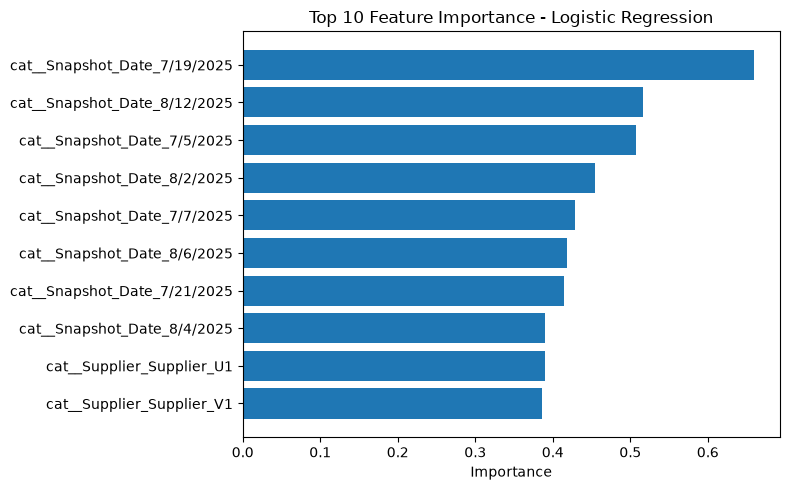


===== XGBoost =====
                          Feature  Importance
10       num__Stock_Coverage_Days    0.054432
3             num__Lead_Time_Days    0.028738
0              num__Current_Stock    0.015523
2              num__Reorder_Level    0.012832
142  cat__Snapshot_Date_8/10/2025    0.007716
36      cat__Supplier_Supplier_E2    0.007548
125  cat__Snapshot_Date_7/23/2025    0.007317
30      cat__Supplier_Supplier_B2    0.007308
167   cat__Snapshot_Date_8/7/2025    0.007273
32      cat__Supplier_Supplier_C2    0.007216


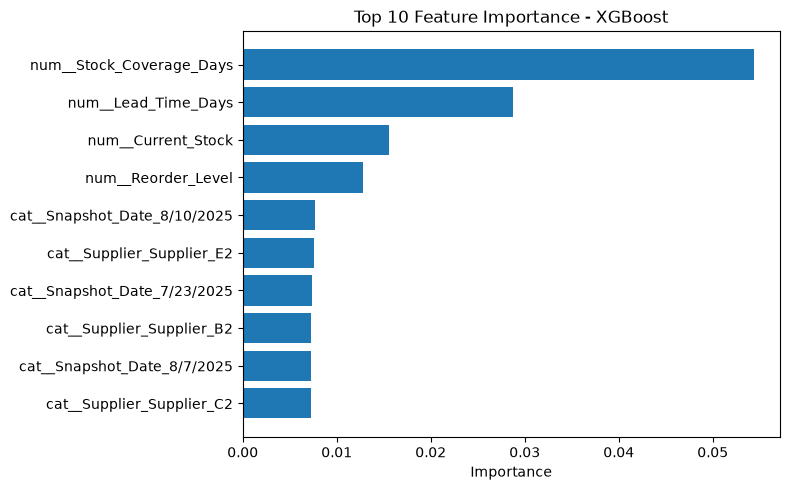


===== Random Forest =====
                          Feature  Importance
10       num__Stock_Coverage_Days    0.208919
0              num__Current_Stock    0.126135
3             num__Lead_Time_Days    0.048006
7    num__Days_Since_Last_Restock    0.035897
2              num__Reorder_Level    0.032862
172            cat__Season_Summer    0.023367
180    cat__Weather_Impact_Medium    0.023190
173            cat__Season_Winter    0.021754
72            cat__Region_Central    0.020855
79          cat__Store_Size_Small    0.019539


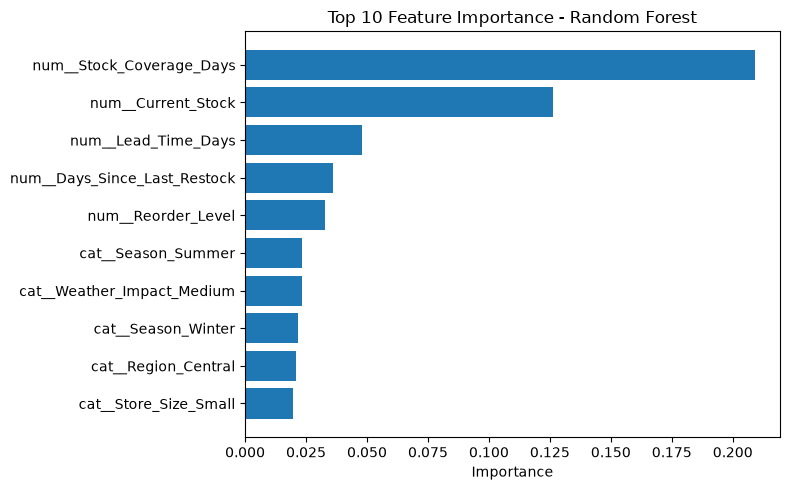

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": lr,
    "XGBoost": xgb,
    "Random Forest": rf
}

for name, model in models.items():

    feature_names = model.named_steps['prep'].get_feature_names_out()

    # Logistic Regression uses coefficients
    if name == "Logistic Regression":
        importance = abs(model.named_steps['model'].coef_[0])

    # Tree-based models use feature_importances_
    else:
        importance = model.named_steps['model'].feature_importances_

    fi = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    print(f"\n===== {name} =====")
    print(fi.head(10))

    # Plot Top 10 Features
    plt.figure(figsize=(8, 5))
    plt.barh(fi["Feature"][:10][::-1], fi["Importance"][:10][::-1])
    plt.title(f"Top 10 Feature Importance - {name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()




 ======================= MODEL NAME : Logistic Regression =======================





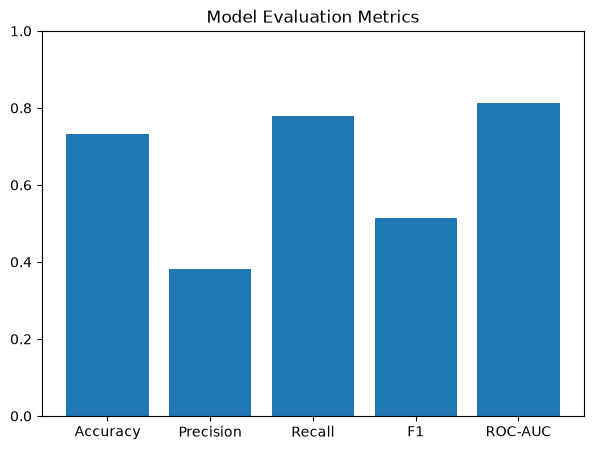




 ======================= MODEL NAME : XGBoost =======================





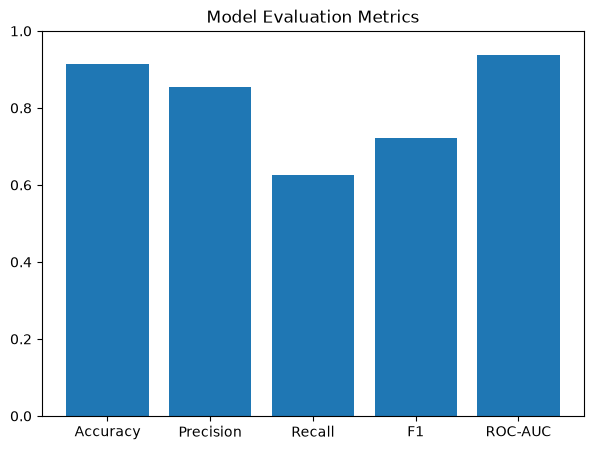




 ======================= MODEL NAME : Random Forest =======================





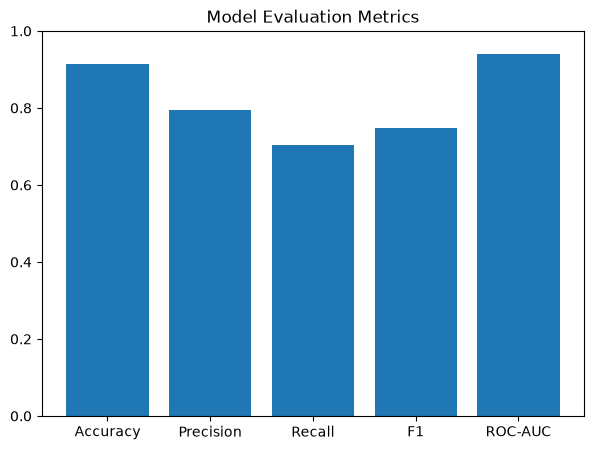

In [9]:
models = {
    "Logistic Regression": lr,
    "XGBoost": xgb,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n\n\n ======================= MODEL NAME : {name} =======================\n\n\n")
    metrics = {
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4)
    }

    plt.figure(figsize=(7,5))
    plt.bar(metrics.keys(), metrics.values())
    plt.ylim(0,1)
    plt.title("Model Evaluation Metrics")
    filename = name.replace(" ", "_")

    plt.savefig(
    fr"C:\Users\AiK\SmartShelf AI\Model Reports\{filename}_Metrics_Comparisons.png",
    dpi=300,
    bbox_inches="tight"
    )
    plt.show()

In [10]:
results_df.to_csv("ModelPerformance.csv")
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7325,0.3825,0.7781,0.5129,0.8137
1,XGBoost,0.9130,0.8552,0.6252,0.7223,0.9386
2,Random Forest,0.9137,0.7952,0.7044,0.7471,0.9389


In [11]:
mname = results_df["Model"]

In [12]:
mname

0    Logistic Regression
1                XGBoost
2          Random Forest
Name: Model, dtype: str

In [13]:
acc = results_df["Accuracy"]
pre = results_df["Precision"]
rec = results_df["Recall"]
f1 = results_df["F1"]
rocauc = results_df["ROC-AUC"]

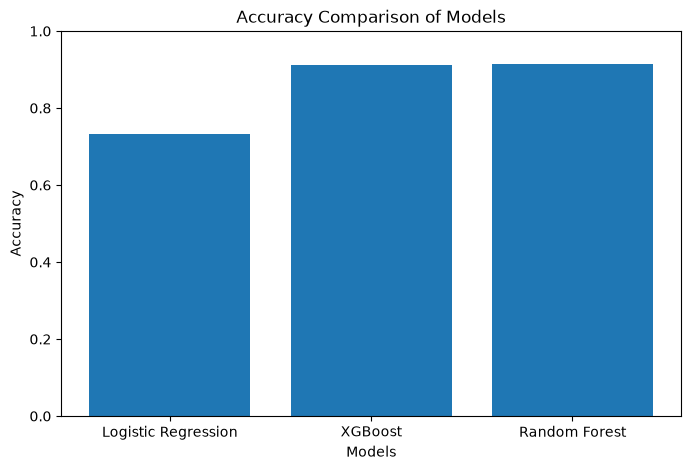

In [14]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.savefig(
    fr"C:\Users\AiK\SmartShelf AI\Model Reports\Models_Accuracy_Comparisons.png",
    dpi=300,
    bbox_inches="tight"
    )
plt.show()

0.8136638956160135
0.93858510018731
0.93887742092162


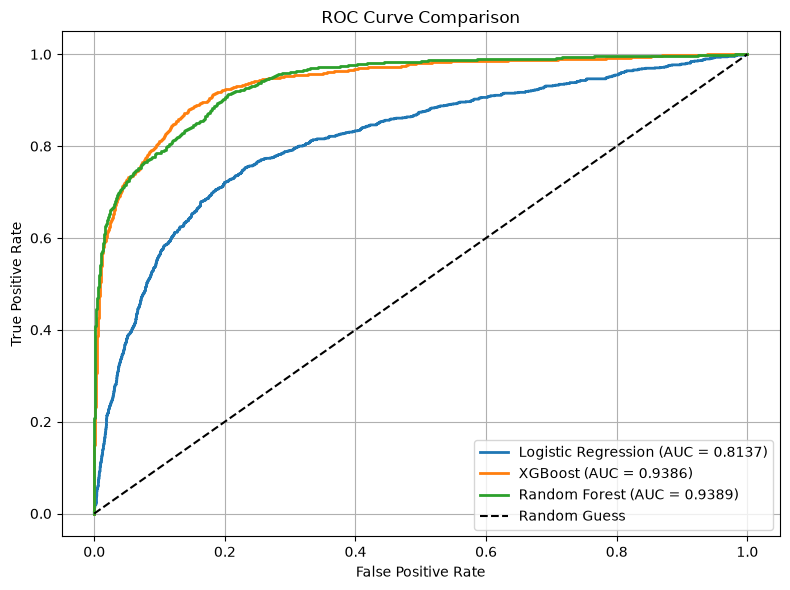

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

models = {
    "Logistic Regression": lr,
    "XGBoost": xgb,
    "Random Forest": rf
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    print(auc)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    r"C:\Users\AiK\SmartShelf AI\Model Reports\ROC_Curve_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()